# 🛠️ EYE-D: Feasibility Check

# 1. yolov8n

In [ ]:
# 필요한 패키지 설치
!pip install ultralytics opencv-python matplotlib

I0511 16:10:33.148617  630446 chttp2_transport.cc:1369] unix:/tmp/tmpu8pjkbx5_milvus_demo.db.sock: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: too_many_pings {grpc_status:14, http2_error:11}
E0511 16:10:33.148731  630446 chttp2_transport.cc:1401] unix:/tmp/tmpu8pjkbx5_milvus_demo.db.sock: Received a GOAWAY with error code ENHANCE_YOUR_CALM and debug data equal to "too_many_pings". Current keepalive time (before throttling): 10000ms


### 1.1. 모델 로드

In [9]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 사전 학습된 YOLOv8 nano 모델 로드 (가중치가 없으면 자동으로 다운로드 됨)
model = YOLO('yolov8n.pt')
print("YOLOv8 모델 로드 완료!")

YOLOv8 모델 로드 완료!


### 1.2. 이미지 추론 (Inference)


image 1/1 /home/torious/projects/tmp/EYE-D/edge/notebooks/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 91.5ms
Speed: 5.0ms preprocess, 91.5ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 480)


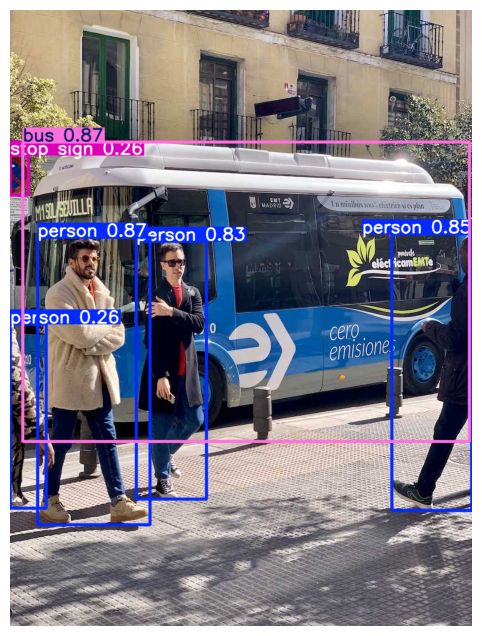

In [2]:
# 샘플 이미지 URL을 사용하여 추론 실행
image_url = 'https://ultralytics.com/images/bus.jpg'

# conf: 신뢰도 임계값 (0.25 이상의 정확도를 가진 객체만 탐지)
results = model.predict(source=image_url, conf=0.25)

# 예측 결과 시각화 준비
result = results[0]
img_with_boxes = result.plot() # 바운딩 박스가 그려진 넘파이 배열(BGR 형식) 반환

# Matplotlib를 이용하여 결과 출력 (BGR -> RGB 변환 필요)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### 1.3. 결과 데이터 분석
예측된 객체의 클래스, 신뢰도(Confidence), 바운딩 박스 좌표를 추출해봅니다.

In [3]:
boxes = result.boxes  # 바운딩 박스 정보 객체

for box in boxes:
    # 1. 클래스 ID 및 이름
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    
    # 2. 신뢰도 (Confidence Score)
    conf = float(box.conf[0])
    
    # 3. 바운딩 박스 좌표 (x1, y1, x2, y2)
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    
    print(f"탐지됨: {class_name} (신뢰도: {conf:.2f}) | 좌표: [{x1}, {y1}, {x2}, {y2}]")

탐지됨: bus (신뢰도: 0.87) | 좌표: [22, 231, 805, 756]
탐지됨: person (신뢰도: 0.87) | 좌표: [48, 398, 245, 902]
탐지됨: person (신뢰도: 0.85) | 좌표: [669, 392, 809, 877]
탐지됨: person (신뢰도: 0.83) | 좌표: [221, 405, 344, 857]
탐지됨: person (신뢰도: 0.26) | 좌표: [0, 550, 63, 873]
탐지됨: stop sign (신뢰도: 0.26) | 좌표: [0, 254, 32, 324]


# 2. Multi-Object Tracking (MOT) Tutorial

이 노트북은 `boxmot` 라이브러리와 `ultralytics` YOLOv8을 활용하여 영상 내 다수의 객체를 탐지하고 각각에게 고유 ID를 부여하여 연속적으로 추적(Tracking)하는 기본적인 방법을 다룹니다.

In [ ]:
# 필요한 패키지 설치
!pip install ultralytics boxmot opencv-python matplotlib

### 2.1. 모델 및 트래커 로드
객체 탐지를 위한 YOLO 모델과, 객체 간 ID를 유지해 주는 ByteTrack 트래커를 초기화합니다.

In [2]:
import sys
import boxmot

print(sys.executable)
print(boxmot.__file__)
print(boxmot.__version__)

/home/torious/anaconda3/envs/cv_poc/bin/python
/home/torious/anaconda3/envs/cv_poc/lib/python3.10/site-packages/boxmot/__init__.py
17.0.0


### 2.2. 샘플 영상에 추적(Tracking) 적용
비디오 클립을 읽어 각 프레임마다 탐지(Detection) 후 트래커(Tracker)를 업데이트하는 루프를 구성해봅니다.

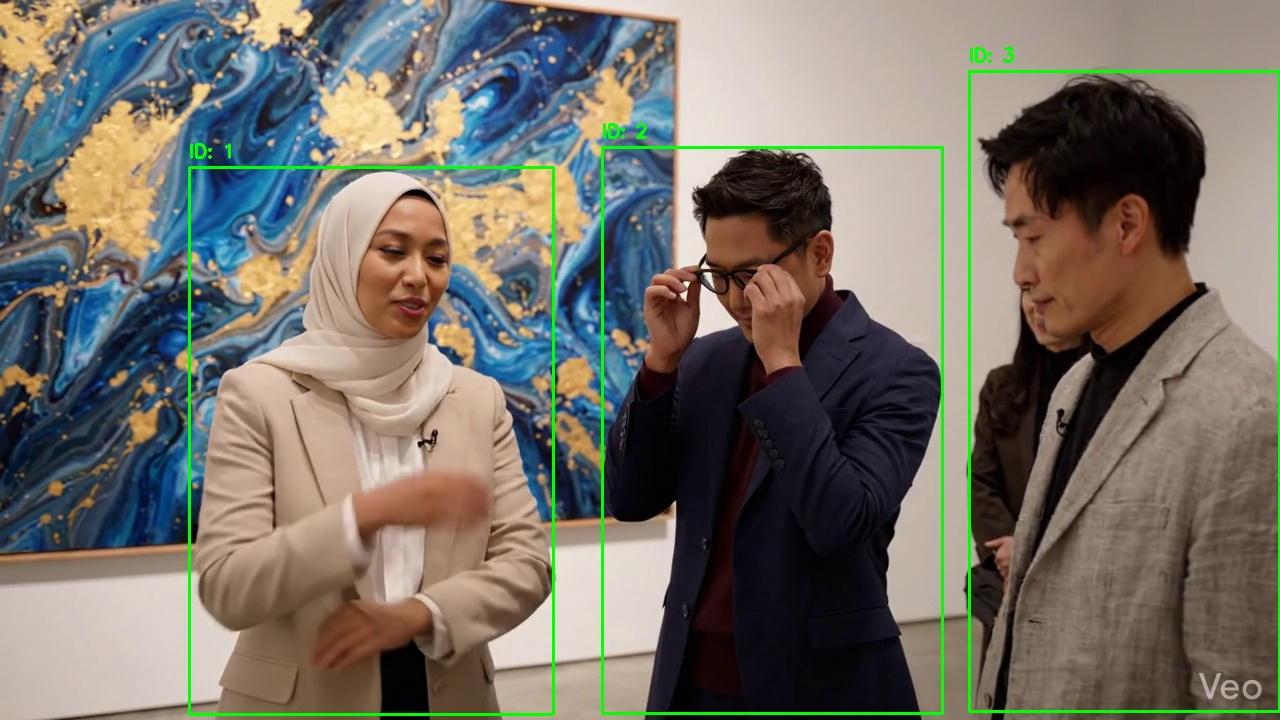

In [ ]:

from IPython.display import display, Image, clear_output

import cv2
import numpy as np
import torch
from boxmot.trackers.tracker_zoo import create_tracker
from ultralytics import YOLO

# 1. 초기 설정
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
half = True if device != 'cpu' else False
tracker = create_tracker('botsort', reid_weights='osnet_x0_25_msmt17.pt', device=device, half=half)
model = YOLO('yolov8n.pt') 
cap = cv2.VideoCapture('../../data/g1.mp4') # 노트북 파일 위치에 따라 경로 주의!

frame_count = 0

# 2. 실시간 스트리밍 루프
while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_count > 50:
        break

    # 객체 탐지 및 트래킹
    results = model.predict(frame, conf=0.4, verbose=False)
    if len(results[0].boxes) > 0:
        dets = results[0].boxes.data.cpu().numpy()
    else:
        dets = np.empty((0, 6))

    tracks = tracker.update(dets, frame)
    # 시각화 (바운딩 박스)
    for track in tracks:
        x1, y1, x2, y2, track_id = map(int, track[:5])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f"ID: {track_id}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # OpenCV 이미지를 Jupyter에서 렌더링하기 위해 JPG 포맷으로 인코딩
    _, jpeg = cv2.imencode('.jpg', frame)
    
    # 기존에 렌더링된 이미지를 지우고 새 프레임으로 덮어쓰기
    clear_output(wait=True)
    display(Image(data=jpeg.tobytes()))

    frame_count += 1

cap.release()

# 3. RE-ID Tutorial

* `torchreid` 라이브러리를 사용하여 탐지된 객체로부터 특징 벡터(Feature Vector)를 추출하는 방법을 다룹니다.

In [ ]:
# RE-ID 실습에 필요한 의존성 패키지를 설치합니다.
# tensorboard: torchreid 로깅용 의존성
# gdown: 사전 학습된 모델 다운로드용
# torchreid: Re-ID 핵심 라이브러리
!pip install tensorboard gdown torchreid

# 설치 후 커널을 재시작(Restart Kernel)해야 할 수도 있습니다.

### 3.1. Re-ID 모델 로드

In [2]:
try:
    from torchreid.utils import FeatureExtractor
except ImportError:
    # 일부 버전에서는 reid 서브패키지 아래에 위치할 수 있습니다.
    from torchreid.reid.utils import FeatureExtractor

# OSNet-light 모델 로드 (market1501 데이터셋으로 학습된 가중치 사용)
reid_model = FeatureExtractor(
    model_name='osnet_x0_25',
    device='cpu'  # 또는 'cuda'
)
print("Re-ID 모델 로드 완료!")

/home/torious/anaconda3/envs/cv_poc/lib/python3.10/site-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1rb8UN5ZzPKRc_xvtHlyDh-cSz88YX9hs
To: /home/torious/.cache/torch/checkpoints/osnet_x0_25_imagenet.pth
100%|██████████| 2.97M/2.97M [00:00<00:00, 7.62MB/s]


Successfully loaded imagenet pretrained weights from "/home/torious/.cache/torch/checkpoints/osnet_x0_25_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
Model: osnet_x0_25
- params: 203,568
- flops: 82,316,000
Re-ID 모델 로드 완료!


### 3.2. 특징 벡터 추출

* 탐지된 사람의 이미지를 모델 입력 크기에 맞춰 리사이징한 후 특징 벡터를 추출합니다.

추출된 벡터 차원: torch.Size([1, 512])
벡터 샘플 (앞 10개): tensor([1.4410, 0.0000, 0.0000, 2.8606, 0.0000, 0.0000, 0.0000, 0.2419, 2.9711, 0.0000])


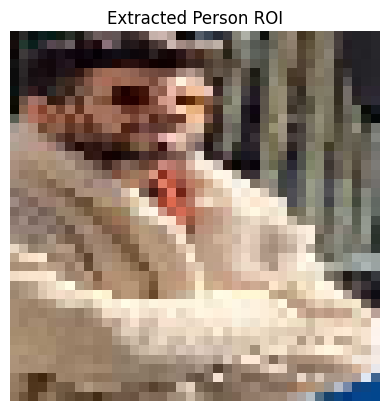

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 샘플 이미지 로드
img = cv2.imread('bus.jpg')

# 이미지에서 임의의 사람 영역 크롭 (예: YOLO 탐지 결과)
# bus.jpg에서 첫 번째 사람 영역 대략적인 좌표 [y1:y2, x1:x2]
person_roi = img[400:600, 100:200]

if person_roi.size > 0:
    # 모델 입력 크기(256, 128)로 리사이징
    person_roi_resized = cv2.resize(person_roi, (80, 80))
    
    # 특징 벡터 추출
    features = reid_model(person_roi_resized)
    
    print(f"추출된 벡터 차원: {features.shape}")
    print(f"벡터 샘플 (앞 10개): {features[0][:10]}")
    
    # 시각화
    plt.imshow(cv2.cvtColor(person_roi_resized, cv2.COLOR_BGR2RGB))
    plt.title("Extracted Person ROI")
    plt.axis('off')
    plt.show()
else:
    print("ROI 영역이 유효하지 않습니다.")

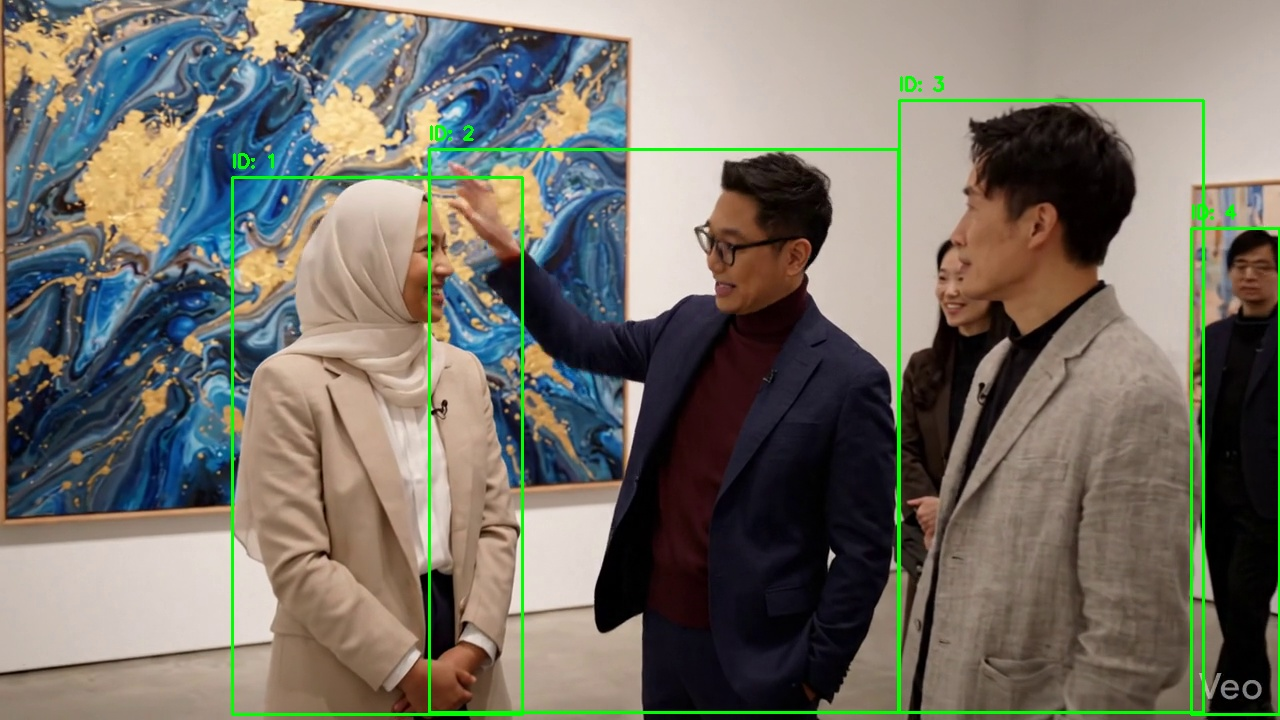

In [16]:

from IPython.display import display, Image, clear_output

import cv2
import numpy as np
import torch
from boxmot.trackers.tracker_zoo import create_tracker
from ultralytics import YOLO

# 1. 초기 설정
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
half = True if device != 'cpu' else False
tracker = create_tracker('botsort', reid_weights='osnet_x0_25_msmt17.pt', device=device, half=half)
model = YOLO('yolov8n.pt') 
cap = cv2.VideoCapture('../../data/g1.mp4') # 노트북 파일 위치에 따라 경로 주의!

frame_count = 0

# 2. 실시간 스트리밍 루프
while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_count > 50:
        break

    # 객체 탐지 및 트래킹
    results = model.predict(frame, conf=0.4, verbose=False)
    if len(results[0].boxes) > 0:
        dets = results[0].boxes.data.cpu().numpy()
    else:
        dets = np.empty((0, 6))

    tracks = tracker.update(dets, frame)
    # 시각화 (바운딩 박스)
    for track in tracks:
        x1, y1, x2, y2, track_id = map(int, track[:5])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f"ID: {track_id}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # OpenCV 이미지를 Jupyter에서 렌더링하기 위해 JPG 포맷으로 인코딩
    _, jpeg = cv2.imencode('.jpg', frame)
    
    # 기존에 렌더링된 이미지를 지우고 새 프레임으로 덮어쓰기
    clear_output(wait=True)
    display(Image(data=jpeg.tobytes()))

    frame_count += 1

cap.release()

### 3.3. 실시간 Re-ID 결과 시각화

* YOLOv8 탐지기, DeepOCSORT 추적기, 그리고 OSNet Re-ID 모델을 결합하여 실시간으로 객체를 추적하고 특징 벡터를 추출합니다.
* 추출된 Re-ID 특징 벡터의 일부를 바운딩 박스 위에 표시하여 실시간 계산 여부를 확인합니다.

In [25]:
from IPython.display import display, Image, clear_output
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import json
from pathlib import Path
from boxmot.trackers.tracker_zoo import create_tracker
from ultralytics import YOLO
try:
    from torchreid.utils import FeatureExtractor
except ImportError:
    from torchreid.reid.utils import FeatureExtractor

# 1. 모델 및 트래커 초기화
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
half = True if device != 'cpu' else False

model = YOLO('yolov8n.pt')
reid_model = FeatureExtractor(model_name='osnet_x0_25', device='cpu')
tracker = create_tracker('botsort', reid_weights='osnet_x0_25_msmt17.pt', device=device, half=half)

# 2. 비디오 및 저장 데이터 초기화
video_path = '../../data/g1.mp4'
if not os.path.exists(video_path):
    video_path = 'output.mp4'

cap = cv2.VideoCapture(video_path)
print(f"비디오 로드: {video_path}")

# 임베딩 데이터를 저장할 리스트
embedding_records = []

try:
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret or frame_count > 10: # 10프레임 제한
            break
        
        frame_count += 1
        results = model(frame, verbose=False)
        det = results[0].boxes.xyxy.cpu().numpy()
        conf = results[0].boxes.conf.cpu().numpy()
        cls = results[0].boxes.cls.cpu().numpy()
        
        mask = cls == 0
        if len(det[mask]) > 0:
            dets_with_cls = np.hstack((det[mask], conf[mask, np.newaxis], cls[mask, np.newaxis]))
            tracks = tracker.update(dets_with_cls, frame)
            
            for track in tracks:
                x1, y1, x2, y2, track_id = map(int, track[:5])
                
                roi = frame[y1:y2, x1:x2]
                if roi.size > 0:
                    roi_resized = cv2.resize(roi, (256, 128))
                    features = reid_model(roi_resized)
                    
                    # 텐서를 리스트로 변환하여 저장
                    vector = features[0].cpu().numpy().tolist()
                    embedding_records.append({
                        "frame": frame_count,
                        "track_id": int(track_id),
                        "embedding": vector
                    })
                    
                    # 시각화용 텍스트
                    feat_sample = vector[:3]
                    label = f"ID:{track_id} [{feat_sample[0]:.2f}, ...]"
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # 시각화
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Re-ID Data Collection - Frame {frame_count}")
        plt.axis('off')
        display(plt.gcf())
        clear_output(wait=True)
        plt.close()

except Exception as e:
    print(f"오류 발생: {e}")
finally:
    cap.release()
    
    # 3. 데이터 파일 저장 및 요약 출력
    output_file = 'embeddings_results.json'
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(embedding_records, f, indent=4)
    
    print("\n" + "="*50)
    print(f"데이터 수집 완료! (총 {len(embedding_records)}개 레코드)")
    print(f"파일 저장 경로: {os.path.abspath(output_file)}")
    
    # ID별 요약 정보 출력
    unique_ids = sorted(list(set(r['track_id'] for r in embedding_records)))
    print(f"감지된 추적 ID 목록: {unique_ids}")
    
    if unique_ids:
        print("\n[ID별 임베딩 샘플 (첫 5개 값)]")
        for tid in unique_ids:
            # 해당 ID의 첫 번째 벡터 가져오기
            sample_vec = next(r['embedding'] for r in embedding_records if r['track_id'] == tid)
            print(f"Track ID {tid}: {sample_vec[:5]} ... (길이: {len(sample_vec)})")
    print("="*50)


데이터 수집 완료! (총 153개 레코드)
파일 저장 경로: /home/torious/projects/tmp/EYE-D/edge/notebooks/embeddings_results.json
감지된 추적 ID 목록: [1, 2, 3, 4, 5]

[ID별 임베딩 샘플 (첫 5개 값)]
Track ID 1: [0.0, 0.0, 1.2874425649642944, 0.46490606665611267, 0.0] ... (길이: 512)
Track ID 2: [0.0, 0.0, 0.0, 0.0, 0.0] ... (길이: 512)
Track ID 3: [0.0, 0.0, 1.0940219163894653, 0.0, 0.0] ... (길이: 512)
Track ID 4: [0.0, 0.0, 0.0, 1.2278810739517212, 0.0] ... (길이: 512)
Track ID 5: [1.8237348794937134, 0.0, 0.0, 0.45791929960250854, 0.22457721829414368] ... (길이: 512)


# 4. Local Vector DB (Qdrant)

추출된 임베딩 벡터를 효율적으로 관리하고 검색하기 위해 벡터 데이터베이스인 **Qdrant**를 사용합니다. 
파일(JSON) 저장은 기록용으로 좋지만, 수만 명의 인물 데이터에서 유사한 인물을 50ms 이내에 찾아내기 위해서는 벡터 인덱싱 기술이 필수적입니다.

### 4.1. Qdrant 클라이언트 설치


In [ ]:
!pip install qdrant-client

### 4.2. Qdrant 초기화 및 컬렉션 생성
튜토리얼의 편의를 위해 별도의 서버 설치 없이 메모리(`:memory:`) 모드로 실행합니다.

In [2]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
import json
import os

# 1. Qdrant 클라이언트 초기화 (메모리 모드)
client = QdrantClient(":memory:")
COLLECTION_NAME = "person_reid"

# 2. 컬렉션 생성 (OSNet 특징 벡터 크기는 512차원)
client.recreate_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=512, distance=Distance.COSINE),
)
print(f"컬렉션 '{COLLECTION_NAME}'이 생성되었습니다.")

# 3. JSON 데이터 로드
input_file = 'embeddings_results.json'
if os.path.exists(input_file):
    with open(input_file, 'r') as f:
        embedding_data = json.load(f)
    
    # 4. Qdrant에 포인트(데이터) 삽입
    points = []
    for i, record in enumerate(embedding_data):
        points.append(PointStruct(
            id=i, 
            vector=record['embedding'], 
            payload={"track_id": record['track_id'], "frame": record['frame']}
        ))
    
    # 배치 삽입
    client.upsert(collection_name=COLLECTION_NAME, points=points)
    print(f"총 {len(points)}개의 벡터를 Qdrant에 저장했습니다.")
else:
    print("JSON 파일이 없습니다. 3번 섹션을 먼저 실행해 주세요.")


컬렉션 'person_reid'이 생성되었습니다.
총 153개의 벡터를 Qdrant에 저장했습니다.


/tmp/ipykernel_611279/3881946451.py:11: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


### 4.3. 유사 인물 검색 (Vector Search)
수집된 데이터 중 하나를 골라 '쿼리'로 사용하여, DB 내에서 가장 유사한 인물을 찾아봅니다.


In [5]:
if len(embedding_data) > 0:
    # 테스트용 쿼리: 첫 번째 데이터의 벡터를 검색 쿼리로 사용
    query_vector = embedding_data[0]['embedding']
    target_id = embedding_data[0]['track_id']
    
    print(f"검색 쿼리 대상: Track ID {target_id}")
    
    try:
        # 방법 1: 최신 버전에서 권장되는 query_points 사용
        search_result = client.query_points(
            collection_name=COLLECTION_NAME,
            query=query_vector,
            limit=3
        ).points
    except AttributeError:
        # 방법 2: 기존 search 메서드 사용
        search_result = client.search(
            collection_name=COLLECTION_NAME,
            query_vector=query_vector,
            limit=3
        )

    print("\n[검색 결과]")
    for hit in search_result:
        # hit 객체의 구조에 따라 데이터 추출 (PointStruct 또는 ScoredPoint)
        payload = hit.payload
        score = hit.score
        print(f"ID: {payload['track_id']} (Frame {payload['frame']}) | 유사도: {score:.4f}")
else:
    print("검색할 데이터가 없습니다.")


검색 쿼리 대상: Track ID 1

[검색 결과]
ID: 1 (Frame 1) | 유사도: 1.0000
ID: 1 (Frame 2) | 유사도: 0.9861
ID: 1 (Frame 3) | 유사도: 0.9553


### 4.5. Milvus Lite

**Milvus Lite**는 Milvus 벡터 DB의 경량화 버전으로, 별도의 서버나 컨테이너 없이 파이썬 라이브러리(`pymilvus`)만으로 로컬 환경에서 벡터 검색 기능을 제공합니다. 

- **장점**: 설치가 매우 간편함, 엣지 장비(Jetson) 리소스 최소화, Milvus 클라우드/서버와 호환됨.
- **용도**: 엣지 단에서의 실시간 Re-ID 검색 및 프로토타이핑.

In [ ]:
!pip install pymilvus 
!pip install milvus-lite

In [4]:
from pymilvus import MilvusClient
import numpy as np

# 1. Milvus Lite 초기화 (로컬 파일 기반 저장)
db_name = "milvus_demo.db"
client = MilvusClient(db_name)

COLLECTION_NAME = "person_reid_test"

# 2. 기존 컬렉션이 있다면 삭제 (테스트용)
if client.has_collection(COLLECTION_NAME):
    client.drop_collection(COLLECTION_NAME)

# 3. 컬렉션 생성 (512차원 특징 벡터 기준)
client.create_collection(
    collection_name=COLLECTION_NAME,
    dimension=512,  # OSNet 특징 벡터 크기
)
print(f"컬렉션 '{COLLECTION_NAME}' 생성 완료.")

# 4. 가상 데이터 생성 및 삽입
# 실제 환경에서는 추출된 Re-ID 벡터를 사용합니다.
data = [
    {"id": i, "vector": np.random.random(512).tolist(), "subject_id": f"person_{i}"}
    for i in range(10)
]

res = client.insert(
    collection_name=COLLECTION_NAME,
    data=data
)
print(f"{len(data)}개의 데이터가 삽입되었습니다.")

# 5. 유사도 검색 수행
# 임의의 쿼리 벡터 생성
query_vectors = [np.random.random(512).tolist()]

res = client.search(
    collection_name=COLLECTION_NAME,
    data=query_vectors,
    limit=3,
    output_fields=["subject_id"] # 결과에 포함할 메타데이터 필드
)

print("\n[Milvus Lite 검색 결과]")
for result in res[0]:
    print(f"ID: {result['entity']['subject_id']} | 거리(Score): {result['distance']:.4f}")


/home/torious/anaconda3/envs/cv_poc/lib/python3.10/site-packages/milvus_lite/__init__.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


컬렉션 'person_reid_test' 생성 완료.
10개의 데이터가 삽입되었습니다.

[Milvus Lite 검색 결과]
ID: person_9 | 거리(Score): 0.7663
ID: person_0 | 거리(Score): 0.7592
ID: person_5 | 거리(Score): 0.7562


* 리소스 비교: Qdrant와 Milvus Lite 중 Orin Nano의 메모리와 CPU를 더 적게 점유하는 라이브러리를 선택
* 영속성: Milvus Lite는 milvus_demo.db와 같은 단일 파일에 데이터를 저장하므로 관리가 편리합니다.